# Task 2 — Crop Rotation Pattern Identification (Local Data)


In [25]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os
import utils
import glob

In [26]:


# Set parameters
years = range(2016, 2026) # Pulls 2016 through 2025
state_name = "Iowa"

# Create a folder to keep your directory clean
output_folder = "cdl_downloads"
os.makedirs(output_folder, exist_ok=True)

# 1. Get the state info
fips, bbox = utils.get_state_info(state_name)

# 2. Download loop
if fips:
    for year in years:
        # Create a proper file path (e.g., "cdl_downloads/cdl_IOWA_2016.tif")
        file_name = f"cdl_{year}_{fips}.tif"
        out_path = os.path.join(output_folder, file_name)
        
        # Call the function with the OUT_PATH, not the bbox!
        utils.download_cdl_tif(year, fips, out_path)
        print("-" * 40)
else:
    print(f"Could not proceed: FIPS code for {state_name} not found.")

FIPS of Iowa is 19
BBOX of Iowa is -54000,1929000,471000,2293000
[CDL 2016] Already exists: cdl_downloads/cdl_2016_19.tif
----------------------------------------
[CDL 2017] Already exists: cdl_downloads/cdl_2017_19.tif
----------------------------------------
[CDL 2018] Already exists: cdl_downloads/cdl_2018_19.tif
----------------------------------------
[CDL 2019] Already exists: cdl_downloads/cdl_2019_19.tif
----------------------------------------
[CDL 2020] Already exists: cdl_downloads/cdl_2020_19.tif
----------------------------------------
[CDL 2021] Already exists: cdl_downloads/cdl_2021_19.tif
----------------------------------------
[CDL 2022] Already exists: cdl_downloads/cdl_2022_19.tif
----------------------------------------
[CDL 2023] Already exists: cdl_downloads/cdl_2023_19.tif
----------------------------------------
[CDL 2024] Already exists: cdl_downloads/cdl_2024_19.tif
----------------------------------------
[CDL 2025] Already exists: cdl_downloads/cdl_2025_19.

## 1. Load Data Stack


In [27]:
# We subsample for visualization speed (every 10th pixel)
# Full resolution would involve ~200 million pixels per year.
step = 10 
stack_list = []
file_pattern = f"cdl_downloads/CDL_{{}}_{fips}.tif"
files = [file_pattern.format(y) for y in years]

print("Loading 10-year CDL stack (subsampled step=10)...")
print(files)
for f in files:
    with rasterio.open(f) as src:
        # Read subsampled
        arr = src.read(1, out_shape=(src.height // step, src.width // step), 
                       resampling=rasterio.enums.Resampling.nearest)
        stack_list.append(arr)
        print(f"  Loaded {os.path.basename(f)} - {arr.shape}")

stack = np.stack(stack_list)
print(f"\nFinal Stack Shape: {stack.shape}")

Loading 10-year CDL stack (subsampled step=10)...
['cdl_downloads/CDL_2016_19.tif', 'cdl_downloads/CDL_2017_19.tif', 'cdl_downloads/CDL_2018_19.tif', 'cdl_downloads/CDL_2019_19.tif', 'cdl_downloads/CDL_2020_19.tif', 'cdl_downloads/CDL_2021_19.tif', 'cdl_downloads/CDL_2022_19.tif', 'cdl_downloads/CDL_2023_19.tif', 'cdl_downloads/CDL_2024_19.tif', 'cdl_downloads/CDL_2025_19.tif']
  Loaded CDL_2016_19.tif - (1167, 1779)
  Loaded CDL_2017_19.tif - (1167, 1779)
  Loaded CDL_2018_19.tif - (1167, 1779)
  Loaded CDL_2019_19.tif - (1167, 1779)
  Loaded CDL_2020_19.tif - (1167, 1779)
  Loaded CDL_2021_19.tif - (1167, 1779)
  Loaded CDL_2022_19.tif - (1167, 1779)
  Loaded CDL_2023_19.tif - (1167, 1779)
  Loaded CDL_2024_19.tif - (1167, 1779)
  Loaded CDL_2025_19.tif - (1167, 1779)

Final Stack Shape: (10, 1167, 1779)


## 2. Classification Logic


In [28]:
CORN = 1
SOYBEAN = 5

is_corn = (stack == CORN)
is_soy = (stack == SOYBEAN)
is_valid = is_corn | is_soy

count_corn = np.sum(is_corn, axis=0)
count_soy = np.sum(is_soy, axis=0)
count_valid = np.sum(is_valid, axis=0)

# 1. Monoculture: 9+ years of the same crop
monoculture = (count_corn >= 9) | (count_soy >= 9)

# 2. Alternation consistency
# Consecutive valid-year pairs
pair_valid = is_valid[:-1] & is_valid[1:]

# Alternation between corn and soybean
alternating_pairs = pair_valid & (stack[:-1] != stack[1:])

n_valid_pairs = np.sum(pair_valid, axis=0)
n_alternating_pairs = np.sum(alternating_pairs, axis=0)

alt_score = np.divide(
    n_alternating_pairs,
    n_valid_pairs,
    out=np.zeros_like(n_alternating_pairs, dtype=float),
    where=n_valid_pairs > 0
)

# Require mostly corn/soy years (>=9) and strong alternation (>=80%)
regular_rotation = (count_valid >= 9) & (alt_score >= 0.8) & (~monoculture)

# Map: 0=Irregular, 1=Monoculture, 2=Regular Rotation
rotation_map = np.zeros(stack[0].shape, dtype=np.uint8)
rotation_map[monoculture] = 1
rotation_map[regular_rotation] = 2

print('Improved classification complete (Alternation Score >= 0.8).')

# Export as GeoTIFF for Task 4 modeling
# with rasterio.open(files[-1]) as src:
#     profile = src.profile
#     profile.update(dtype=rasterio.uint8, count=1, height=rotation_map.shape[0], width=rotation_map.shape[1])
#     with rasterio.open('rotation_map.tif', 'w', **profile) as dst:
#         dst.write(rotation_map, 1)
# print('Rotation map exported to rotation_map.tif')


Improved classification complete (Alternation Score >= 0.8).


In [29]:
from scipy.ndimage import label
import numpy as np

structure = np.ones((3,3), dtype=int)

rotation_parcels, n_rotation = label(rotation_map == 2, structure=structure)
monoculture_parcels, n_mono = label(rotation_map == 1, structure=structure)

print("Rotation pseudo-parcels:", n_rotation)
print("Monoculture pseudo-parcels:", n_mono)

Rotation pseudo-parcels: 18654
Monoculture pseudo-parcels: 11266


## 3. Visualization and Stats


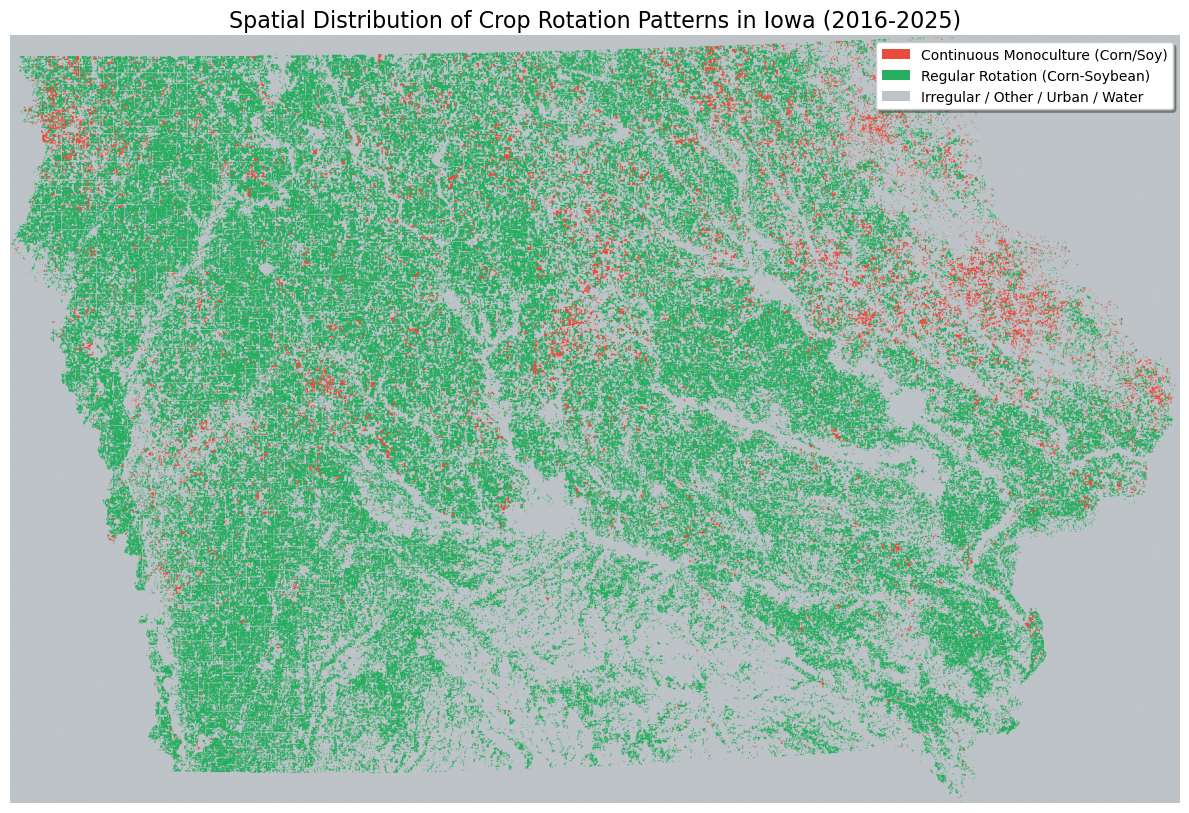


Rotation Statistics:
                    Class   Pixels  Percent
0       Irregular / Other  1384275    66.68
1  Continuous Monoculture    56121     2.70
2        Regular Rotation   635697    30.62


In [30]:
plt.figure(figsize=(12, 10))
cmap = ListedColormap(['#bdc3c7', '#e74c3c', '#27ae60']) # Light Gray, Alizarin Red, Nephritis Green
plt.imshow(rotation_map, cmap=cmap)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Continuous Monoculture (Corn/Soy)'),
    Patch(facecolor='#27ae60', label='Regular Rotation (Corn-Soybean)'),
    Patch(facecolor='#bdc3c7', label='Irregular / Other / Urban / Water')
]
plt.legend(handles=legend_elements, loc='upper right', frameon=True, shadow=True)
plt.title(f"Spatial Distribution of Crop Rotation Patterns in {state_name} (2016-2025)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig(f"plots/rotation_patterns_{state_name}.png", dpi=150, bbox_inches='tight')
plt.show()

# Statistics
total_pix = rotation_map.size
stats = []
labels = ['Irregular / Other', 'Continuous Monoculture', 'Regular Rotation']
for i in range(3):
    cnt = np.sum(rotation_map == i)
    pct = (cnt / total_pix) * 100
    stats.append({'Class': labels[i], 'Pixels': int(cnt), 'Percent': round(pct, 2)})

df_stats = pd.DataFrame(stats)
print("\nRotation Statistics:")
print(df_stats)
df_stats.to_csv(f"summary/rotation_stats_{state_name}.csv", index=False)

In [31]:
import pandas as pd

rot_ids, rot_counts = np.unique(rotation_parcels[rotation_parcels > 0], return_counts=True)
mono_ids, mono_counts = np.unique(monoculture_parcels[monoculture_parcels > 0], return_counts=True)

df_rot = pd.DataFrame({"parcel_id": rot_ids, "pixels": rot_counts, "class": "Rotation"})
df_mono = pd.DataFrame({"parcel_id": mono_ids, "pixels": mono_counts, "class": "Monoculture"})

df_parcels = pd.concat([df_rot, df_mono], ignore_index=True)

print(df_parcels.head())

for f in glob.glob("cdl_downloads/*.tif"): os.remove(f)

   parcel_id  pixels     class
0          1       3  Rotation
1          2       1  Rotation
2          3       5  Rotation
3          4       7  Rotation
4          5       9  Rotation
